0. Import Libraries

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

0. Import Datasets

In [46]:
dayEvents = pd.read_csv('./dataset/cleaned_dayEvents.csv')
goldPrice = pd.read_csv('./dataset/cleaned_GoldPrice.csv')

In [47]:
dayEvents.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date
0,11,Pokhran-II Nuclear Tests,1,5,1998,India,Nuclear & WMD,Pokhran,India declared itself a nuclear state,International community,Atal Bihari Vajpayee,Mixed,1998-05-01
1,12,Mumbai Terror Attacks,1,11,2008,India,Terrorism & Violence,Mumbai,Highlighted the threat of international terrorism,Citizens of Mumbai,LashkarUnknowneUnknownTaiba,Negative,2008-11-01
2,18,Operation Blue Star,1,6,1984,India,Military & Conflict,Amritsar,Removal of armed militants from Golden Temple ...,Sikh community,"Indian Government, Sikh militants",Negative,1984-06-01
3,19,Kargil War,1,5,1999,India,Military & Conflict,"Kargil, Ladakh",India regained control of Kargil; heightened p...,Indian Armed Forces,"Indian Government, Pakistani Military",Positive,1999-05-01
4,20,Right to Information Act Enacted,1,6,2005,India,Legal & Legislation,India,Empowered citizens to seek information from pu...,Indian citizens,Government of India,Positive,2005-06-01


In [48]:
goldPrice.head()

,Date,Price(USD),Price(THB),Gold Change %
0,1979-01-01,233.7,4511.3,NaN
1,1979-02-01,251.3,4985.7,7.531023
2,1979-03-01,240.1,4812.9,-4.456825
3,1979-04-01,245.3,4891.0,2.165764
4,1979-05-01,274.6,5560.8,11.944558


In [49]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Sl. No                              386 non-null    int64 
 1   Name of Incident                    386 non-null    object
 2   Day                                 386 non-null    int64 
 3   Month                               386 non-null    int64 
 4   Year                                386 non-null    int64 
 5   Country                             386 non-null    object
 6   Type of Event                       386 non-null    object
 7   Place Name                          386 non-null    object
 8   Impact                              386 non-null    object
 9   Affected Population                 386 non-null    object
 10  Important Person/Group Responsible  386 non-null    object
 11  Outcome                             386 non-null    object

Change Type to Date datatype

In [50]:
# Change Type to Date datatype
dayEvents['Date'] = pd.to_datetime(dayEvents['Date'])
goldPrice['Date'] = pd.to_datetime(goldPrice['Date'])

In [51]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386 entries, 0 to 385
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              386 non-null    int64         
 1   Name of Incident                    386 non-null    object        
 2   Day                                 386 non-null    int64         
 3   Month                               386 non-null    int64         
 4   Year                                386 non-null    int64         
 5   Country                             386 non-null    object        
 6   Type of Event                       386 non-null    object        
 7   Place Name                          386 non-null    object        
 8   Impact                              386 non-null    object        
 9   Affected Population                 386 non-null    object        
 10  Important Person/Group Res

Sort Date by Month and Year

In [52]:
dayEvents = dayEvents.sort_values(['Year','Month'])

In [53]:
dayEvents.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date
192,609,1979 Iranian Revolution,1,2,1979,Iran,Political,Iran,"Establishment of the Islamic Republic of Iran,...",Iranian citizens,Ayatollah Khomeini,Mixed,1979-02-01
76,174,One-Child Policy Introduced,1,9,1979,China,Political,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed,1979-09-01
187,531,Speak Mandarin Campaign Launched,1,9,1979,Singapore,Cultural & Religious,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive,1979-09-01
173,499,Juhayman al-Otaybi's Seizure of the Grand Mosque,1,11,1979,Saudi Arabia,Terrorism & Violence,Mecca,A twoUnknownweek siege that challenged the Sau...,"Saudi Arabian citizens, pilgrims",Juhayman alUnknownOtaybi,Negative,1979-11-01
96,245,Soviet-Afghan War,1,12,1979,USSR,Military & Conflict,Afghanistan,A costly and ultimately unsuccessful attempt b...,Afghan and Soviet citizens,Leonid Brezhnev,Negative,1979-12-01


Remove unnessary Outcome (Ongoing)

In [54]:
dayEvents = dayEvents[ dayEvents['Outcome'] != 'Ongoing']

In [55]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 385 entries, 192 to 254
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              385 non-null    int64         
 1   Name of Incident                    385 non-null    object        
 2   Day                                 385 non-null    int64         
 3   Month                               385 non-null    int64         
 4   Year                                385 non-null    int64         
 5   Country                             385 non-null    object        
 6   Type of Event                       385 non-null    object        
 7   Place Name                          385 non-null    object        
 8   Impact                              385 non-null    object        
 9   Affected Population                 385 non-null    object        
 10  Important Person/Group Respon

Merge Data

In [56]:
df = dayEvents.merge(
    goldPrice,
    on="Date",
    how="left"
).dropna()

In [57]:
df["Gold Change %"].describe()

count    383.000000
mean       0.814158
std        5.312541
min      -17.377049
25%       -2.223720
50%        0.455270
75%        3.488459
max       27.539062
Name: Gold Change %, dtype: float64

In [58]:
df["Gold Change %"].value_counts().head()

Gold Change %
-1.260860    5
 7.091796    5
 0.787278    5
-4.205607    4
 1.961447    4
Name: count, dtype: int64

In [59]:
df.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date,Price(USD),Price(THB),Gold Change %
0,609,1979 Iranian Revolution,1,2,1979,Iran,Political,Iran,"Establishment of the Islamic Republic of Iran,...",Iranian citizens,Ayatollah Khomeini,Mixed,1979-02-01,251.3,4985.7,7.531023
1,174,One-Child Policy Introduced,1,9,1979,China,Political,Nationwide,Aimed to control the rapidly growing populatio...,Chinese families,Chinese government,Mixed,1979-09-01,397.3,7894.9,26.086957
2,531,Speak Mandarin Campaign Launched,1,9,1979,Singapore,Cultural & Religious,Singapore,Promotion of Mandarin over other Chinese diale...,Chinese Singaporeans,Singaporean Government,Positive,1979-09-01,397.3,7894.9,26.086957
3,499,Juhayman al-Otaybi's Seizure of the Grand Mosque,1,11,1979,Saudi Arabia,Terrorism & Violence,Mecca,A twoUnknownweek siege that challenged the Sau...,"Saudi Arabian citizens, pilgrims",Juhayman alUnknownOtaybi,Negative,1979-11-01,415.7,8260.5,8.821990
4,245,Soviet-Afghan War,1,12,1979,USSR,Military & Conflict,Afghanistan,A costly and ultimately unsuccessful attempt b...,Afghan and Soviet citizens,Leonid Brezhnev,Negative,1979-12-01,512.0,10645.2,23.165745


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 383 entries, 0 to 382
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              383 non-null    int64         
 1   Name of Incident                    383 non-null    object        
 2   Day                                 383 non-null    int64         
 3   Month                               383 non-null    int64         
 4   Year                                383 non-null    int64         
 5   Country                             383 non-null    object        
 6   Type of Event                       383 non-null    object        
 7   Place Name                          383 non-null    object        
 8   Impact                              383 non-null    object        
 9   Affected Population                 383 non-null    object        
 10  Important Person/Group Responsi

## Find Insights

Pairplot Data

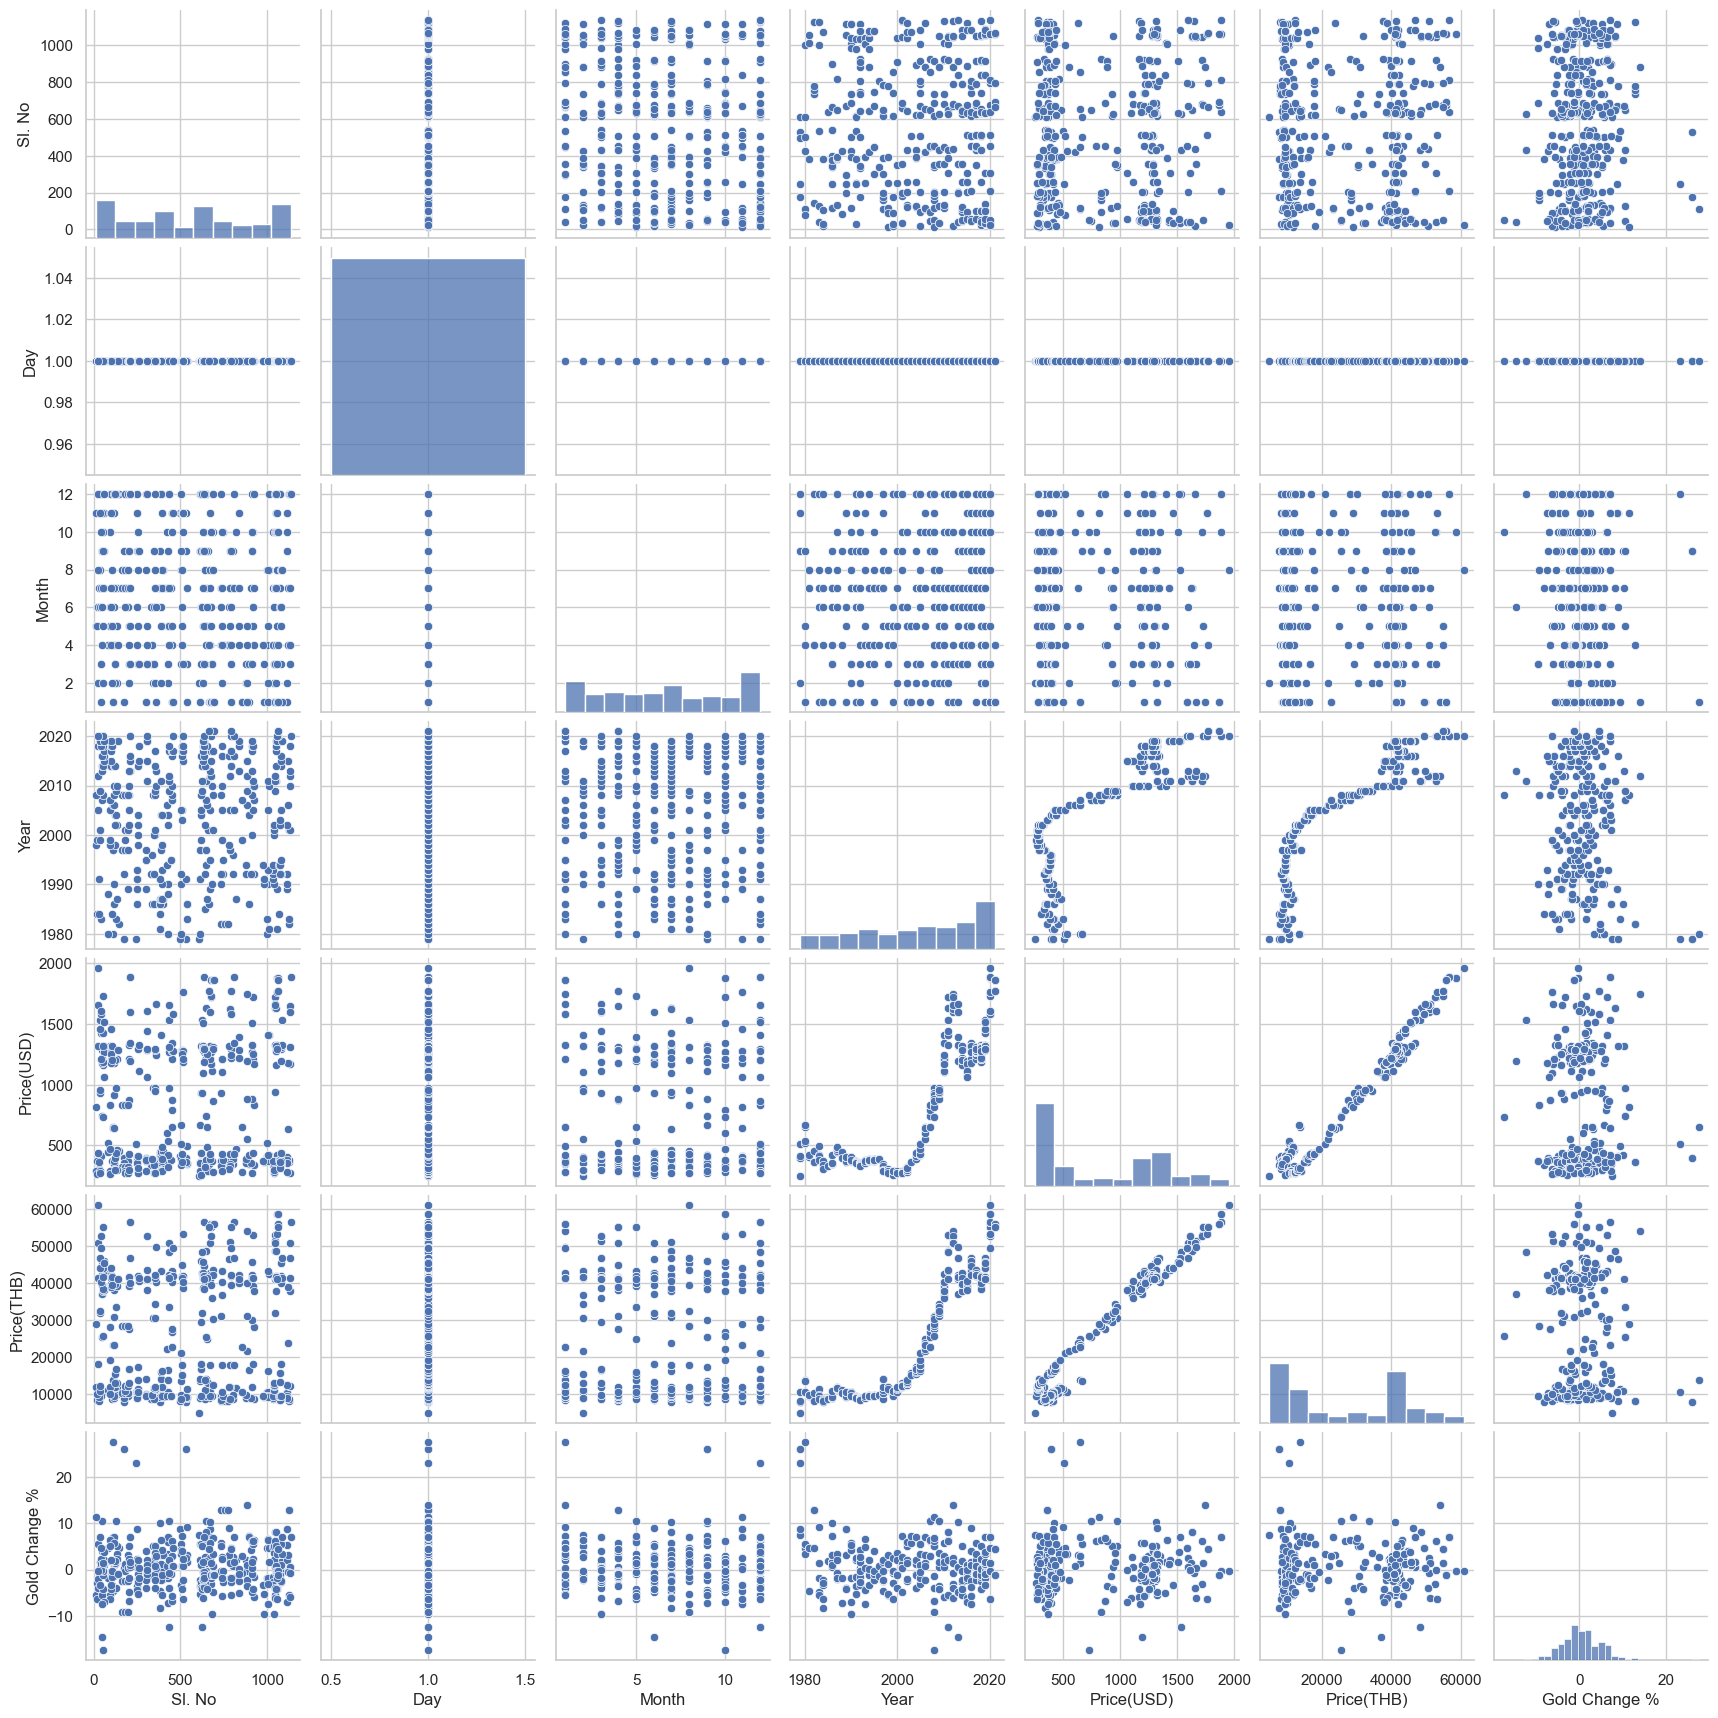

In [61]:
sns.pairplot(df)

In [62]:
df.describe()

,Sl. No,Day,Month,Year,Date,Price(USD),Price(THB),Gold Change %
count,383.000000,383.0,383.000000,383.000000,383,383.000000,383.000000,383.000000
mean,552.767624,1.0,6.634465,2004.258486,2004-09-22 12:20:40.731070464,849.234987,26942.956397,0.814158
min,11.000000,1.0,1.000000,1979.000000,1979-02-01 00:00:00,251.300000,4985.700000,-17.377049
25%,227.000000,1.0,4.000000,1993.000000,1993-10-01 12:00:00,368.450000,10362.050000,-2.223720
50%,539.000000,1.0,7.000000,2007.000000,2007-01-01 00:00:00,666.800000,23933.800000,0.455270
75%,848.000000,1.0,10.000000,2016.000000,2016-04-01 00:00:00,1291.000000,41726.950000,3.488459
max,1137.000000,1.0,12.000000,2021.000000,2021-04-01 00:00:00,1957.400000,60917.600000,27.539062
std,352.216669,0.0,3.457606,12.285799,NaN,514.541767,16533.502326,5.312541


Heatmap: Correlations columns

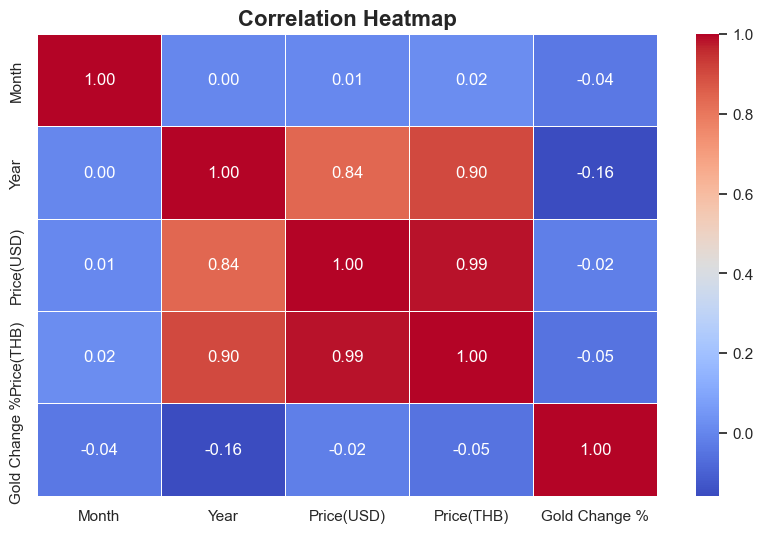

In [63]:
numeric_df = df.select_dtypes(include=['int64','float64']).drop(columns=['Sl. No','Day'], errors='ignore').corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.show()

Heatmap: Event Type & Outcome

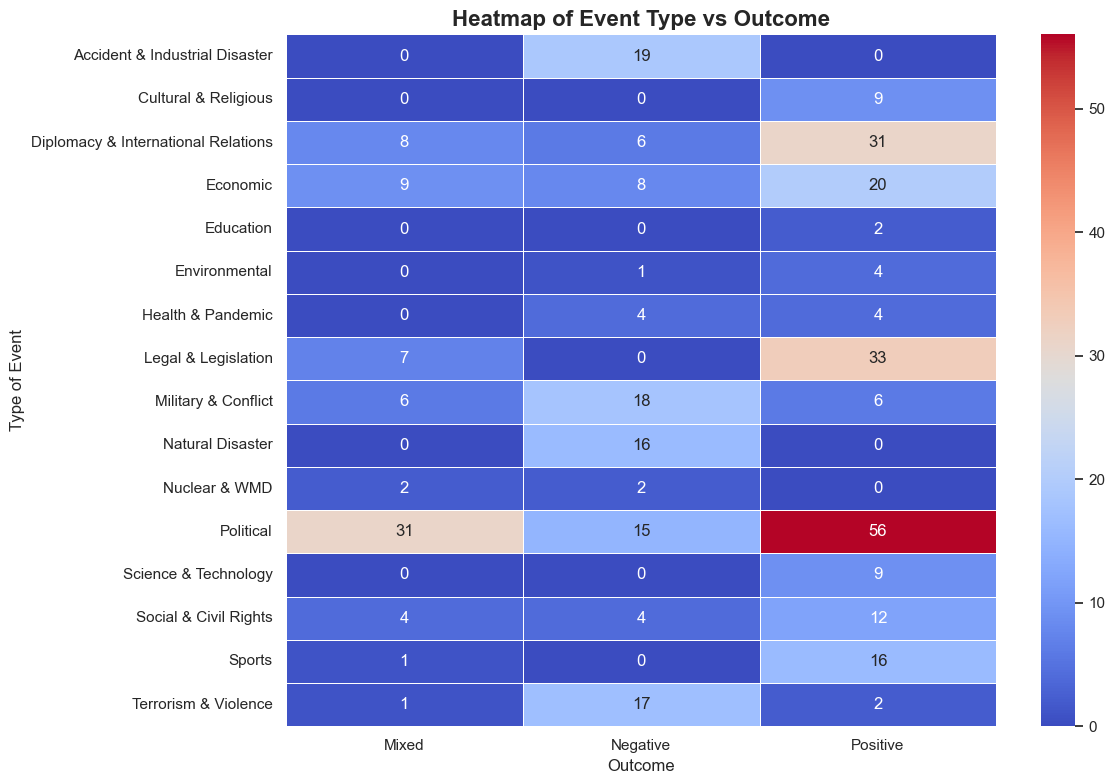

In [64]:
# remove type Ongoing
df_filtered = df[df["Outcome"] != "Ongoing"]

# สร้างตารางความถี่
event_outcome = pd.crosstab(df_filtered["Type of Event"], df_filtered["Outcome"])

plt.figure(figsize=(12,8))

sns.heatmap(
    event_outcome,
    annot=True,
    fmt="d",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap of Event Type vs Outcome", fontsize=16, fontweight="bold")
plt.xlabel("Outcome")
plt.ylabel("Type of Event")

plt.tight_layout()
plt.show()

Outcome % by Event Type

<Figure size 1400x700 with 0 Axes>

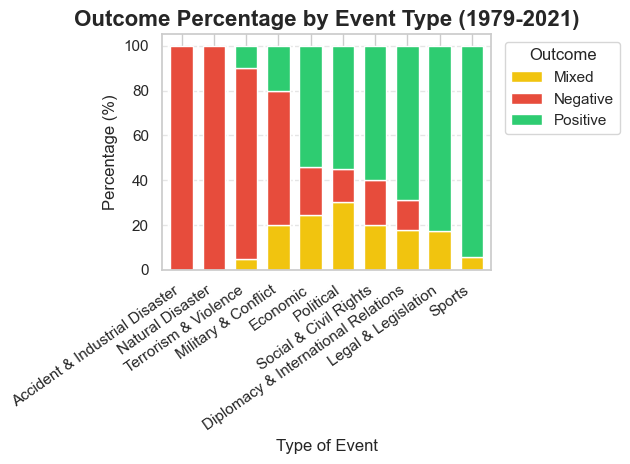

In [65]:
sns.set_style("whitegrid")

event_outcome = pd.crosstab(df["Type of Event"], df["Outcome"])
event_outcome_pct = event_outcome.div(event_outcome.sum(axis=1), axis=0) * 100

top_events = df["Type of Event"].value_counts().head(10).index

event_filtered = event_outcome_pct.loc[top_events]
event_filtered = event_filtered.drop(columns=["Ongoing"], errors="ignore")
event_filtered = event_filtered.sort_values("Positive")

outcome_colors = {
    "Positive": "#2ecc71",
    "Negative": "#e74c3c",
    "Mixed": "#f1c40f"  
}

plt.figure(figsize=(14,7))

event_filtered.plot(
    kind="bar",
    stacked=True,
    color=[outcome_colors[col] for col in event_filtered.columns],
    width=0.7
)

plt.title("Outcome Percentage by Event Type (1979-2021)", fontsize=16, weight="bold")
plt.xlabel("Type of Event", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)

plt.xticks(rotation=35, ha="right")

plt.legend(title="Outcome", bbox_to_anchor=(1.02,1))

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Gold Price Change by Outcome

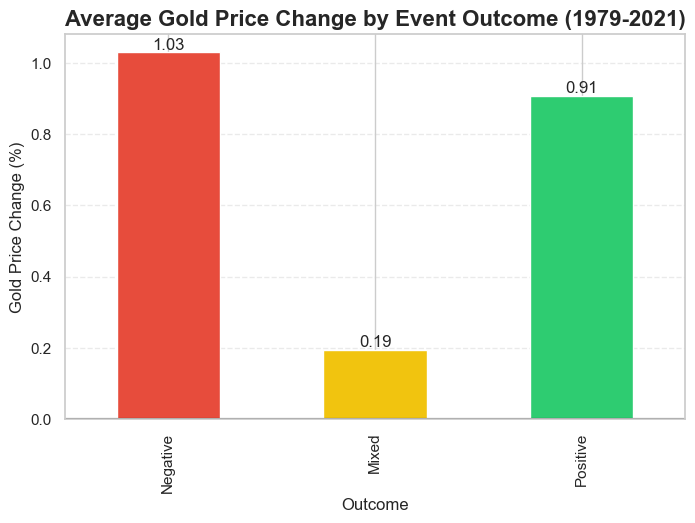

In [66]:
merged = df[df["Outcome"] != "Ongoing"]

df2 = merged.groupby("Outcome")["Gold Change %"].mean()

order = ["Negative","Mixed","Positive"]
df2 = df2.reindex(order)

ax = df2.plot(
    kind="bar",
    figsize=(8,5),
    color=["#e74c3c", "#f1c40f", "#2ecc71"]  
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Gold Price Change by Event Outcome (1979-2021)", fontsize=16, weight="bold")
plt.ylabel("Gold Price Change (%)")
plt.xlabel("Outcome")
plt.axhline(0, color="black")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()


Top 10 Most Incident Countries

C:\Users\User\AppData\Local\Temp\ipykernel_37148\3040932894.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


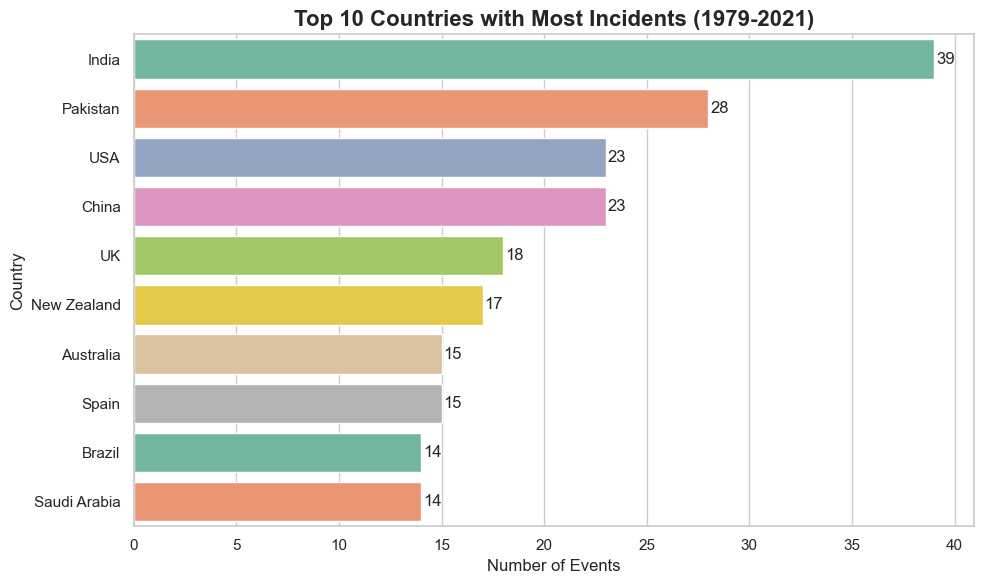

In [67]:
top10_countries = df["Country"].value_counts().head(10).reset_index()
top10_countries.columns = ["Country", "Event Count"]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top10_countries,
    x="Event Count",
    y="Country",
    palette="Set2"
)

# Text on graph
for i in ax.patches:
    ax.text(
        i.get_width() + 0.1,                 # pos x
        i.get_y() + i.get_height()/2,        # pos y
        f'{int(i.get_width())}',             # number
        va='center'
    )

plt.title("Top 10 Countries with Most Incidents (1979-2021)", fontsize=16, fontweight="bold")
plt.xlabel("Number of Events")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

Top 10 Most Frequent Event types

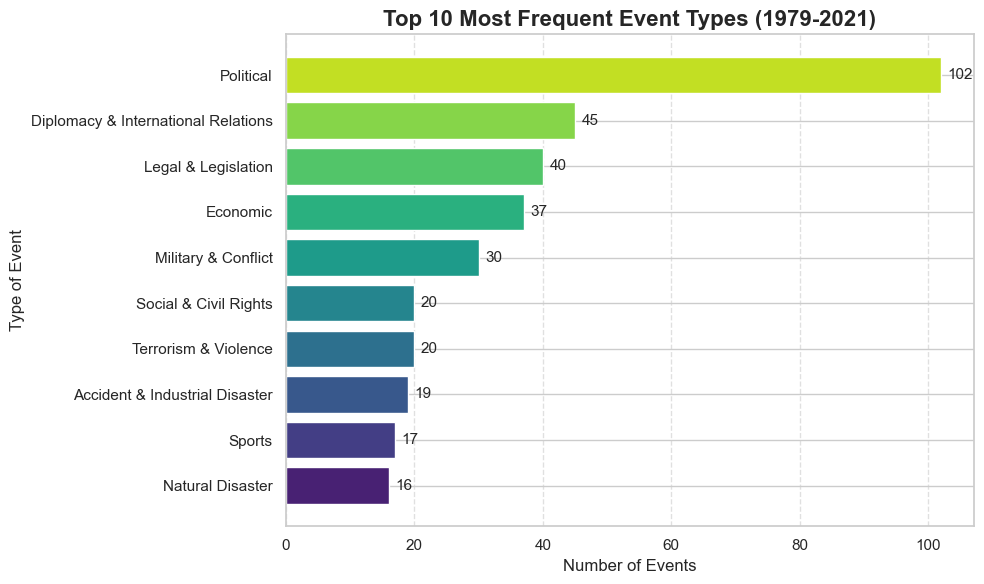

In [68]:
top10_events = df["Type of Event"].value_counts().head(10)
top10_events = top10_events.sort_values()

plt.figure(figsize=(10,6))

sns.set_style("whitegrid")


colors = sns.color_palette("viridis", len(top10_events))
bars = plt.barh(top10_events.index, top10_events.values, color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center',
             fontsize=11)

plt.title("Top 10 Most Frequent Event Types (1979-2021)", fontsize=16, weight='bold')
plt.xlabel("Number of Events", fontsize=12)
plt.ylabel("Type of Event", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Top Event Types Impacting Gold Price

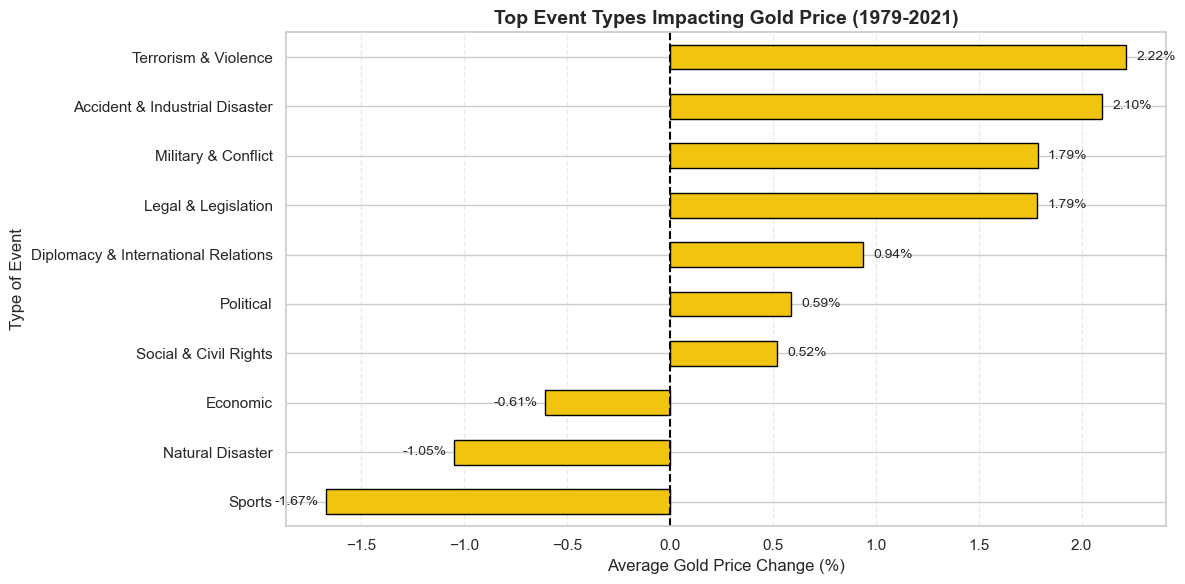

In [69]:
event_counts = df["Type of Event"].value_counts()
valid_events = event_counts[event_counts > 10].index
filtered = df[df["Type of Event"].isin(valid_events)]

event_gold_change = filtered.groupby("Type of Event")["Gold Change %"].mean()
event_gold_change = event_gold_change.sort_values()

plt.figure(figsize=(12,6))

ax = event_gold_change.plot(
    kind="barh",
    color="#f1c40f",
    edgecolor="black"
)

plt.title("Top Event Types Impacting Gold Price (1979-2021)", fontsize=14, weight="bold")
plt.xlabel("Average Gold Price Change (%)")
plt.ylabel("Type of Event")

plt.axvline(0, color="black", linestyle="--")
plt.grid(axis="x", linestyle="--", alpha=0.4)

# ใส่ตัวเลขบนกราฟ
for i, v in enumerate(event_gold_change):
    ax.text(
        v + 0.05 if v >= 0 else v - 0.25,
        i,
        f"{v:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Gold Price vs World Events

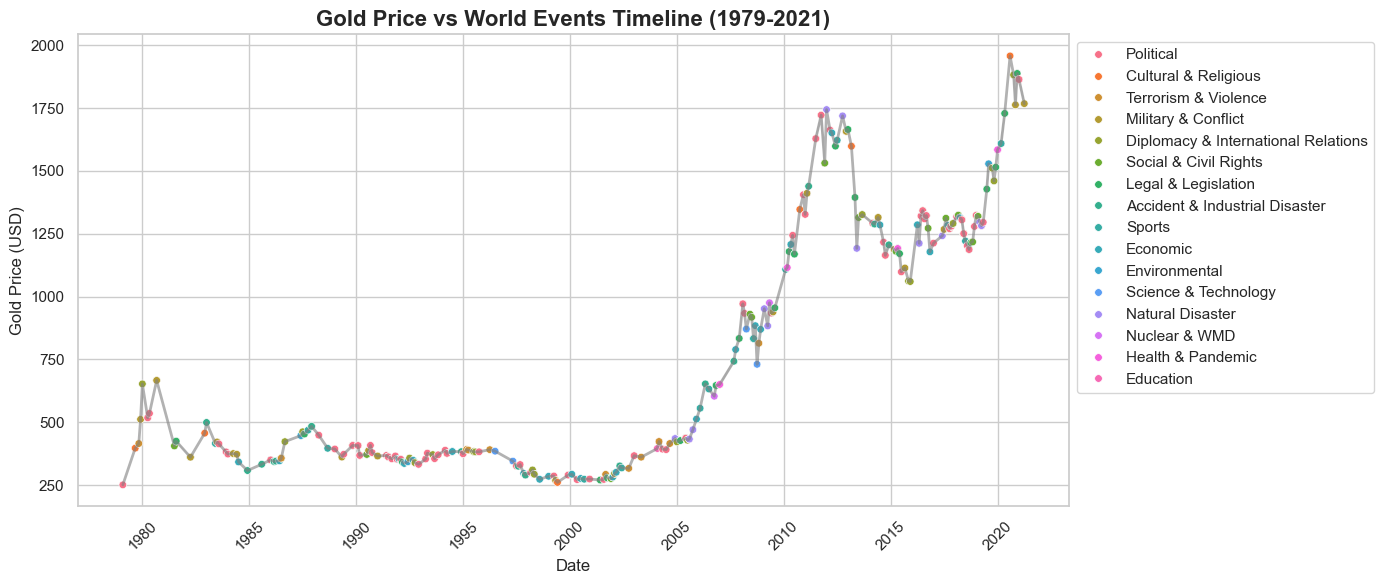

In [70]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df.sort_values("Date"),
    x="Date",
    y="Price(USD)",
    color="gray",
    linewidth=2,
    alpha=0.6
)

sns.scatterplot(
    data=df,
    x="Date",
    y="Price(USD)",
    hue="Type of Event",
    s=30
)

plt.title("Gold Price vs World Events Timeline (1979-2021)", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.tight_layout()
plt.show()

Gold Price vs World Events by Group

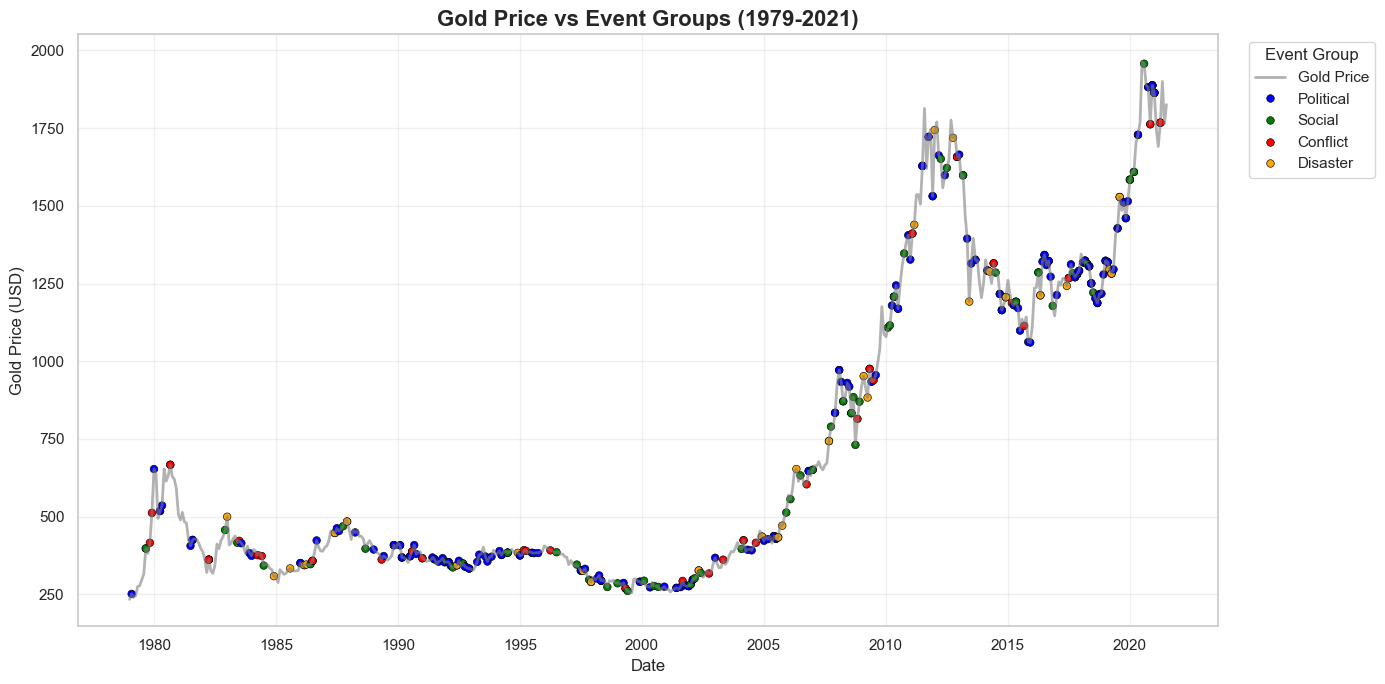

In [71]:
event_group = {
    "Military & Conflict": "Conflict",
    "Terrorism & Violence": "Conflict",
    "Nuclear & WMD": "Conflict",

    "Natural Disaster": "Disaster",
    "Accident & Industrial Disaster": "Disaster",
    "Environmental": "Disaster",

    "Political": "Political",
    "Legal & Legislation": "Political",
    "Diplomacy & International Relations": "Political",
    "Social & Civil Rights": "Political",

    "Education": "Social",
    "Cultural & Religious": "Social",
    "Sports": "Social",
    "Science & Technology": "Social",
    "Health & Pandemic": "Social",
    "Economic": "Social"
}

newdf = df
newdf["Event Group"] = df["Type of Event"].map(event_group)
plt.figure(figsize=(14,7))

# เส้นราคาทอง
plt.plot(
    goldPrice["Date"],
    goldPrice["Price(USD)"],
    color="gray",
    linewidth=2,
    label="Gold Price",
    alpha=0.6
)

# จุด event
sns.scatterplot(
    data=newdf,
    x="Date",
    y="Price(USD)",
    hue="Event Group",
    palette={
        "Conflict":"red",
        "Disaster":"orange",
        "Political":"blue",
        "Social":"green"
    },
    s=30,
    edgecolor="black"
)

plt.title("Gold Price vs Event Groups (1979-2021)", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")

plt.legend(title="Event Group", bbox_to_anchor=(1.02,1))

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Most Important Events

In [72]:
major_events = [
"Gulf War",
"11 Attacks",
"Crisis Impact",
"COVID-19 Pandemic",
'Dot-com',
'Iraq',
'Soviet'
]

event_df = df[df['Name of Incident'].str.contains('|'.join(major_events), case=False, na=False)]
event_df.head(2)

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date,Price(USD),Price(THB),Gold Change %,Event Group
4,245,Soviet-Afghan War,1,12,1979,USSR,Military & Conflict,Afghanistan,A costly and ultimately unsuccessful attempt b...,Afghan and Soviet citizens,Leonid Brezhnev,Negative,1979-12-01,512.0,10645.2,23.165745,Conflict
9,501,Iran-Iraq War and Saudi Involvement,1,9,1980,Saudi Arabia,Military & Conflict,Persian Gulf,"Saudi Arabia supported Iraq, fearing the sprea...",Regional stability,Saudi Government,Mixed,1980-09-01,666.8,13638.5,5.623317,Conflict


In [73]:
for year, events in event_df.groupby('Year')['Name of Incident']:
    print(year)
    for e in events:
        print(" -", e)

1979
 - Soviet-Afghan War
1980
 - Iran-Iraq War and Saudi Involvement
 - Iran-Iraq War
1990
 - Tech Boom and Dot-com Bubble
 - First Gulf War
1991
 - Gulf War
 - Independence from the Soviet Union
 - Dissolution of the Soviet Union
 - Independence from the Soviet Union
2001
 - September 11 Attacks
2008
 - Financial Crisis Impact
2020
 - COVID-19 Pandemic Response
 - COVID-19 Pandemic in the UK


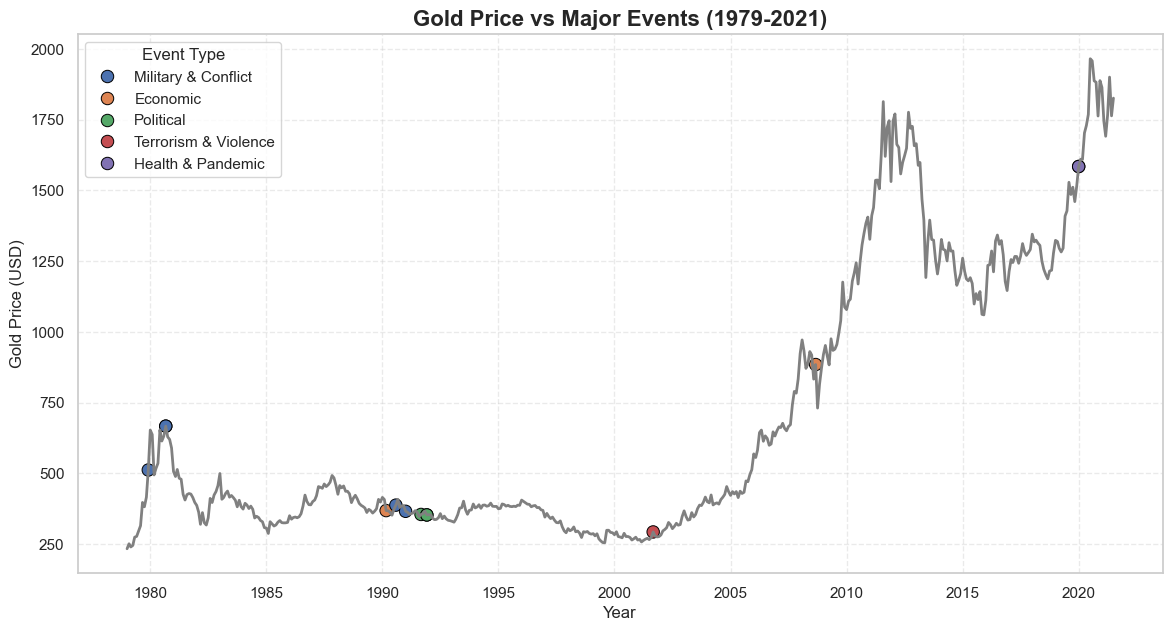

In [74]:
plt.figure(figsize=(14,7))

# plot เหตุการณ์
sns.scatterplot(
    data=event_df,
    x="Date",
    y="Price(USD)",
    hue="Type of Event",
    s=80,
    edgecolor="black"
)

# เส้นราคาทอง
sns.lineplot(
    data=goldPrice,
    x="Date",
    y="Price(USD)",
    color="gray",
    linewidth=2
)


plt.title("Gold Price vs Major Events (1979-2021)", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(title="Event Type")

plt.show()

Gold Price Plot

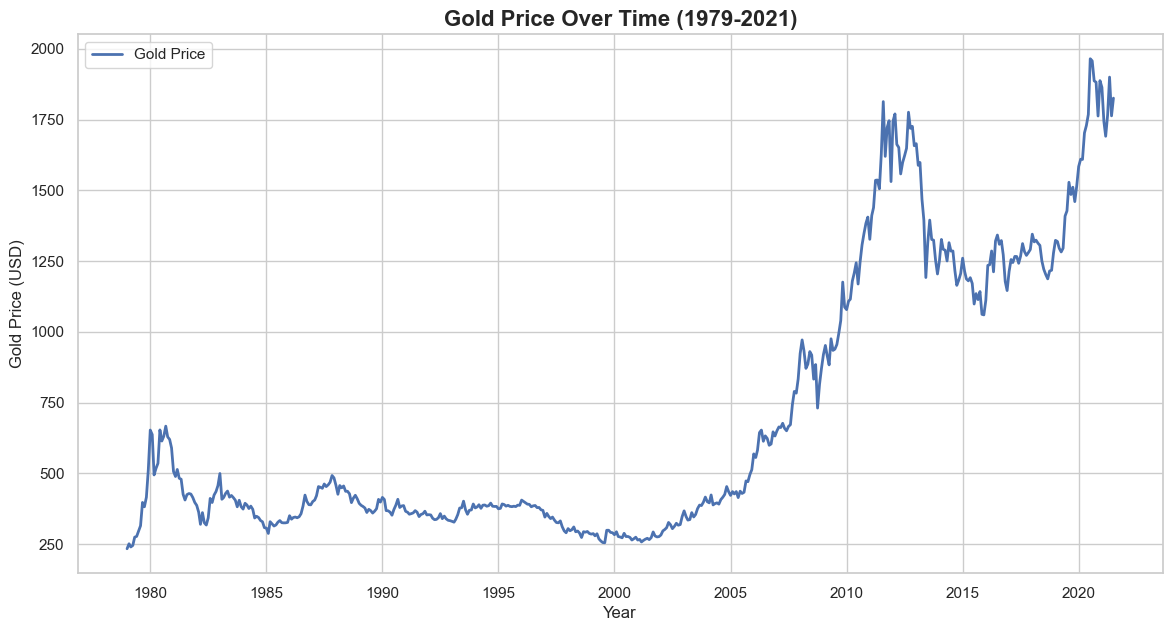

In [75]:
plt.figure(figsize=(14,7))

plt.plot(
    goldPrice["Date"],
    goldPrice["Price(USD)"],
    color="b",
    linewidth=2,
    label="Gold Price"
)

plt.title("Gold Price Over Time (1979-2021)", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

Outcome Distribution in Major Power Countries (1979-2021)

รายชื่อประเทศมหาอำนาจ:
`
[
    'USA', 'China', 'India', 'Russia', 'Germany', 
    'France', 'Japan', 'Saudi Arabia', 'Brazil', 'South Korea'
]
`


<Figure size 1200x800 with 0 Axes>

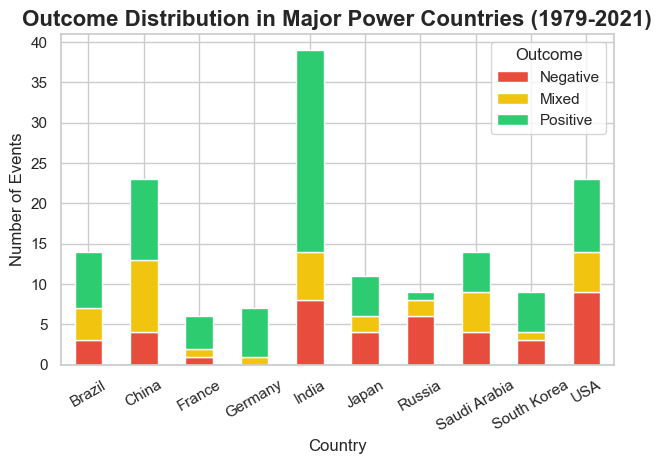

In [76]:

major_powers = [
    'USA', 'China', 'India', 'Russia', 'Germany', 
    'France', 'Japan', 'Saudi Arabia', 'Brazil', 'South Korea'
]

major_df = df[df["Country"].isin(major_powers)]

# นับ Outcome ของแต่ละประเทศ
outcome_country = pd.crosstab(major_df["Country"], major_df["Outcome"])

# เรียงลำดับ column ให้ตรง
outcome_country = outcome_country[["Negative", "Mixed", "Positive"]]

plt.figure(figsize=(12,8))

outcome_country.plot(
    kind="bar",
    stacked=True,
    color=["#e74c3c", "#f1c40f", "#2ecc71"]   # Negative, Mixed, Positive
)

plt.title("Outcome Distribution in Major Power Countries (1979-2021)", fontsize=16, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Number of Events")

plt.xticks(rotation=30)
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Gold Volatility

C:\Users\User\AppData\Local\Temp\ipykernel_37148\3197349597.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


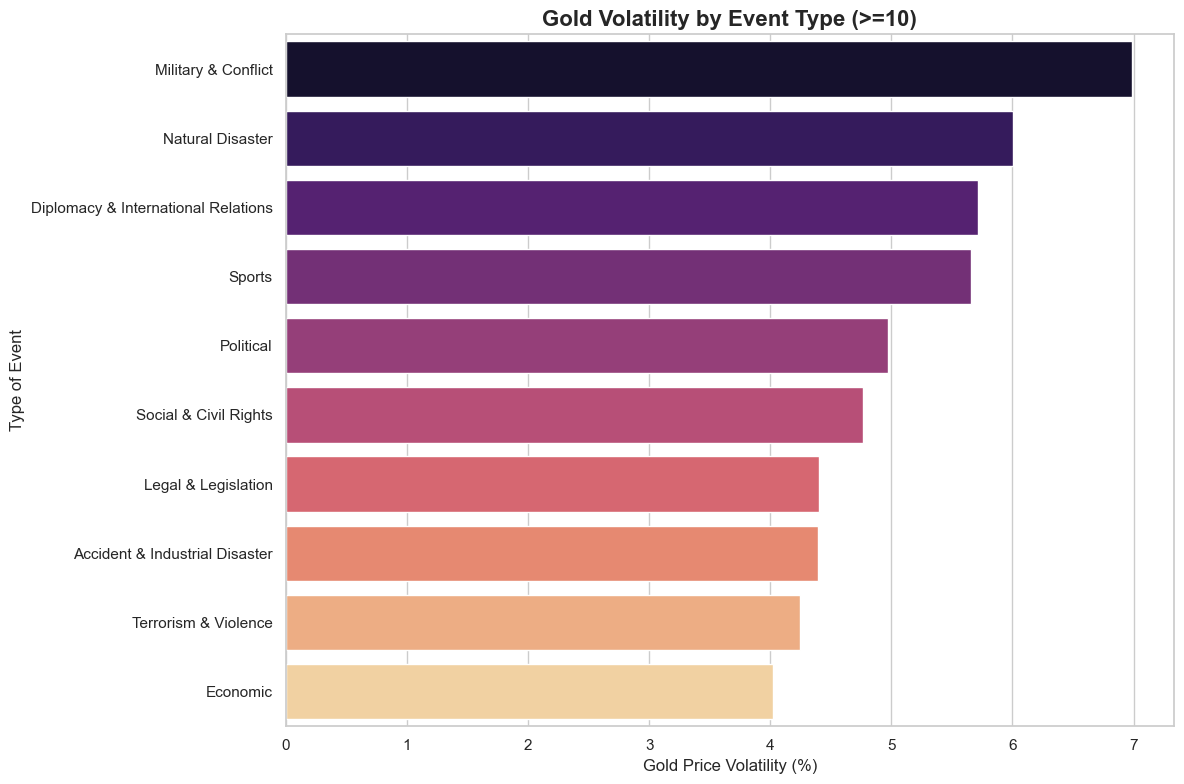

In [89]:
# เลือก event ที่มีจำนวน >= 10
event_counts = df.groupby("Type of Event").size()

valid_events = event_counts[event_counts >= 10].index

filtered_df = df[df["Type of Event"].isin(valid_events)]

# คำนวณ volatility
volatility = (
    filtered_df.groupby("Type of Event")["Gold Change %"]
    .std()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=volatility.values,
    y=volatility.index,
    palette="magma"
)

plt.title("Gold Volatility by Event Type (>=10)", fontsize=16, fontweight="bold")
plt.xlabel("Gold Price Volatility (%)")
plt.ylabel("Type of Event")

plt.tight_layout()
plt.show()

Average Gold Price Change by Country and Event Outcome

In [78]:
major_df['Country'].value_counts()

Country
India           39
China           23
USA             23
Saudi Arabia    14
Brazil          14
Japan           11
South Korea      9
Russia           9
Germany          7
France           6
Name: count, dtype: int64

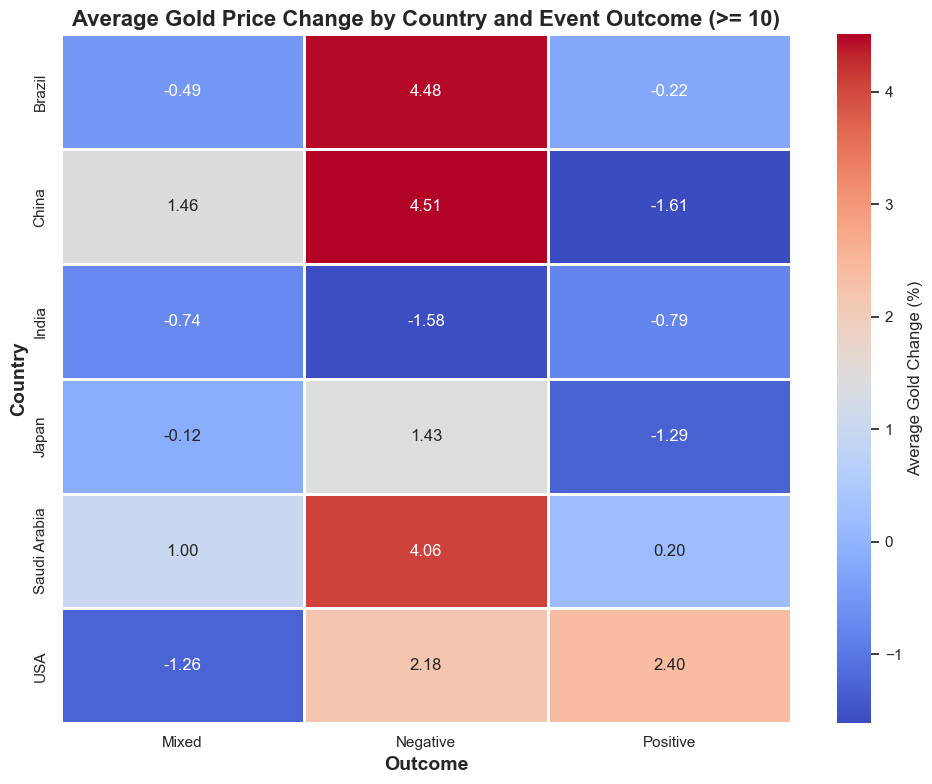

In [79]:
# --- 1. กรองประเทศที่มีจำนวนข้อมูล >= 10 ---
country_counts = major_df["Country"].value_counts()

valid_countries = country_counts[country_counts >= 10].index

filtered_df = major_df[
    major_df["Country"].isin(valid_countries)
]

# --- 2. สร้าง Pivot Table ---
pivot_table = filtered_df.pivot_table(
    values='Gold Change %',
    index='Country',
    columns='Outcome',
    aggfunc='mean'
)

# --- 3. Plot Heatmap ---
plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={'label': 'Average Gold Change (%)'},
    lw=2
)

plt.title('Average Gold Price Change by Country and Event Outcome (>= 10)', fontsize=16, fontweight="bold")
plt.xlabel('Outcome', fontweight="bold", fontsize=14)
plt.ylabel('Country', fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()

# โจทย์

Predict 10 Year of Gold Price Trends

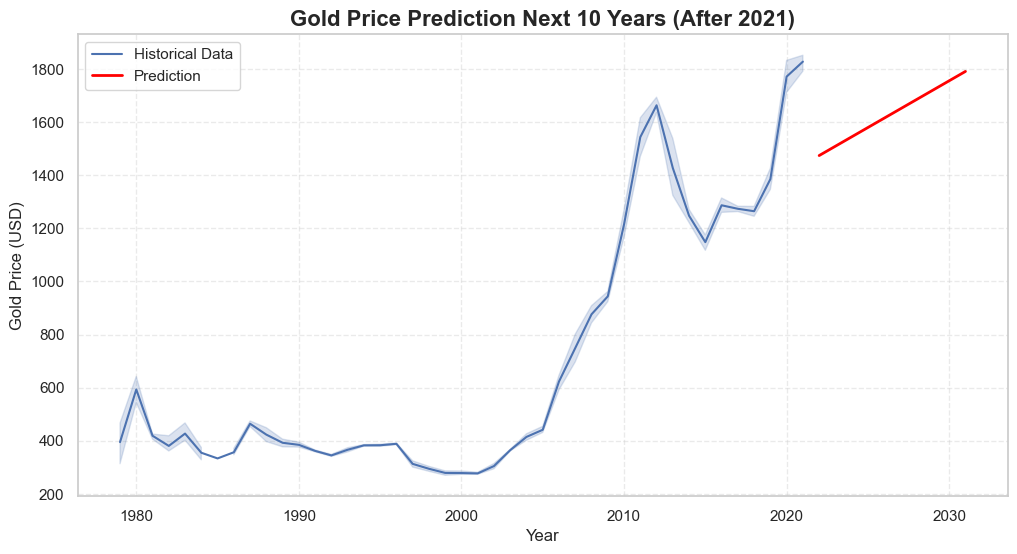

In [80]:
from sklearn.linear_model import LinearRegression

X = df[['Year']]
y = df['Price(USD)']

model = LinearRegression()
model.fit(X,y)


# สร้าง future years
future_years = np.arange(df['Year'].max()+1, df['Year'].max()+11)
future_df = pd.DataFrame({
    "Year": future_years
})

# Predict
pred = model.predict(future_df)

# Plot Graph
plt.figure(figsize=(12,6))

sns.lineplot(
    x=df['Year'],
    y=df['Price(USD)'],
    label="Historical Data"
)

sns.lineplot(
    x=future_years,
    y=pred,
    color="red",
    linewidth=2,
    label="Prediction"
)

plt.xlabel("Year")
plt.ylabel("Gold Price (USD)")

plt.title(
    "Gold Price Prediction Next 10 Years (After 2021)",
    fontsize=16,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend()

plt.show()

Major Powers VS Gold Price

In [81]:
major_powers

['USA',
 'China',
 'India',
 'Russia',
 'Germany',
 'France',
 'Japan',
 'Saudi Arabia',
 'Brazil',
 'South Korea']

- Outcome Positive

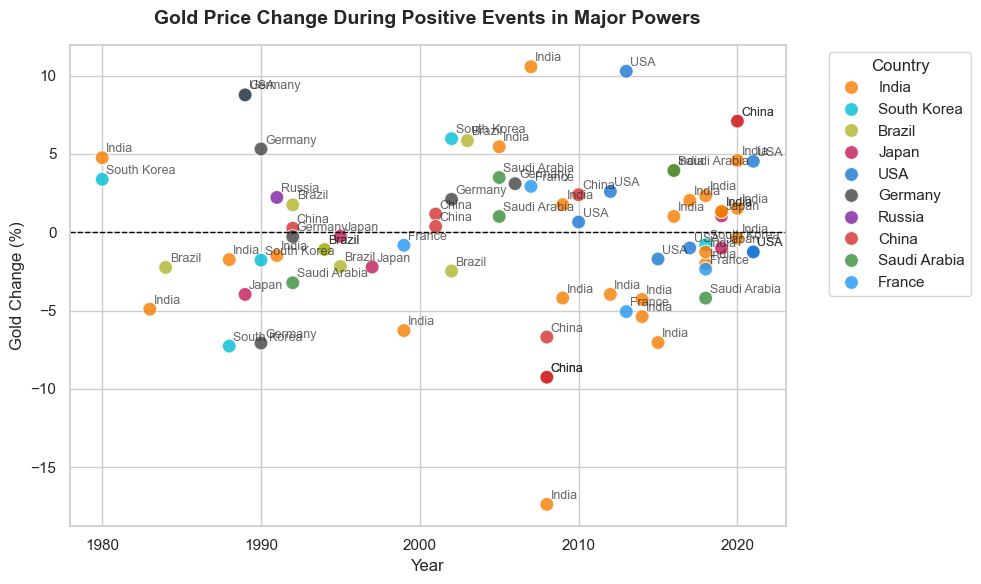

In [82]:
sns.set_theme(style="whitegrid")

major_positive = df[
    (df["Country"].isin(major_powers)) & 
    (df["Outcome"] == "Positive")
]

colors = {
    "USA": "#1976D2",          # Blue (Royal Blue)
    "China": "#D32F2F",        # Red
    "India": "#F57C00",        # Orange (Saffron)
    "Russia": "#7B1FA2",       # Purple (เลี่ยงการใช้สีขาว/แดงซ้ำ)
    "Germany": "#424242",      # Dark Grey/Black
    "France": "#2196F3",       # Azure Blue
    "Japan": "#C2185B",        # Crimson/Pink
    "Saudi Arabia": "#388E3C", # Green
    "Brazil": "#AFB42B",       # Olive/Yellow-Green
    "South Korea": "#00BCD4"   # Cyan/Teal
}

plt.figure(figsize=(10, 6))

scatter_plot = sns.scatterplot(
    data=major_positive, 
    x="Year", 
    y="Gold Change %", 
    hue="Country", 
    palette=colors, 
    s=100,
    edgecolor="w", 
    alpha=0.8
)

for i in range(major_positive.shape[0]):
    plt.text(
        x=major_positive.iloc[i]["Year"] + 0.25, 
        y=major_positive.iloc[i]["Gold Change %"] + 0.35, 
        s=major_positive.iloc[i]["Country"], 
        fontsize=9,
        alpha=0.7
    )

# 6. ตกแต่งรายละเอียดเพิ่มเติม
plt.axhline(0, color="black", linestyle="--", linewidth=1) # เส้น 0 แบบเส้นประ
plt.title("Gold Price Change During Positive Events in Major Powers", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Gold Change (%)", fontsize=12)

# ปรับตำแหน่ง Legend ให้อยู่นอกกราฟ (ถ้าชื่อประเทศเยอะจนบังจุด)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

- Outcome Negative

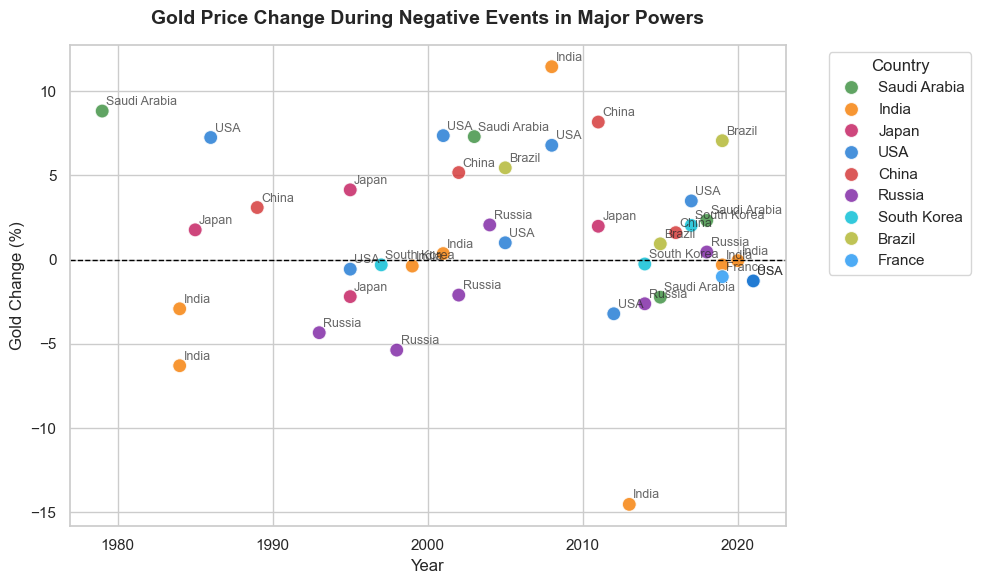

In [83]:
sns.set_theme(style="whitegrid")

major_negative = df[
    (df["Country"].isin(major_powers)) & 
    (df["Outcome"] == "Negative")
]

colors = {
    "USA": "#1976D2",          # Blue (Royal Blue)
    "China": "#D32F2F",        # Red
    "India": "#F57C00",        # Orange (Saffron)
    "Russia": "#7B1FA2",       # Purple (เลี่ยงการใช้สีขาว/แดงซ้ำ)
    "Germany": "#424242",      # Dark Grey/Black
    "France": "#2196F3",       # Azure Blue
    "Japan": "#C2185B",        # Crimson/Pink
    "Saudi Arabia": "#388E3C", # Green
    "Brazil": "#AFB42B",       # Olive/Yellow-Green
    "South Korea": "#00BCD4"   # Cyan/Teal
}

plt.figure(figsize=(10, 6))

scatter_plot = sns.scatterplot(
    data=major_negative, 
    x="Year", 
    y="Gold Change %", 
    hue="Country", 
    palette=colors, 
    s=100,
    edgecolor="w", 
    alpha=0.8
)

for i in range(major_negative.shape[0]):
    plt.text(
        x=major_negative.iloc[i]["Year"] + 0.25, 
        y=major_negative.iloc[i]["Gold Change %"] + 0.35, 
        s=major_negative.iloc[i]["Country"], 
        fontsize=9,
        alpha=0.7
    )

# 6. ตกแต่งรายละเอียดเพิ่มเติม
plt.axhline(0, color="black", linestyle="--", linewidth=1) # เส้น 0 แบบเส้นประ
plt.title("Gold Price Change During Negative Events in Major Powers", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Gold Change (%)", fontsize=12)

# ปรับตำแหน่ง Legend ให้อยู่นอกกราฟ (ถ้าชื่อประเทศเยอะจนบังจุด)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Average Gold Price Change % by Zone

In [84]:
df['Country'].unique()

array(['Iran', 'China', 'Singapore', 'Saudi Arabia', 'USSR', 'Pakistan',
       'India', 'Zimbabwe', 'South Korea', 'Iraq', 'New Zealand',
       'Mauritania', 'Canada', 'UK', 'Argentina', 'Sri Lanka',
       'Burkina Faso', 'Brazil', 'Japan', 'USA', 'Spain', 'Australia',
       'Philippines', 'Angola', 'Germany', 'South Africa', 'Namibia',
       'Kuwait, Iraq', 'Somalia', 'Russia', 'Zambia', 'Uzbekistan',
       'Kazakhstan', 'Italy', 'Mozambique', 'Ethiopia', 'Eritrea',
       'Rwanda', 'North Korea', 'Vietnam', 'France', 'Bhutan',
       'Sierra Leone', 'Algeria', 'Taiwan', 'Maldives', 'Sudan',
       'Indonesia', 'Thailand', 'Nigeria', 'Tunisia', 'Egypt', 'Libya',
       'Uganda', 'South Sudan', 'Zhanaozen', 'Mali',
       'Central African Republic', 'Malaysia', 'Mosul', 'Kenya', 'Chad'],
      dtype=object)

- แบ่งตามโซนทวีป

In [85]:
zone_map = {
    # Asia
    "Iran":"Asia","China":"Asia","Singapore":"Asia","Saudi Arabia":"Asia",
    "Pakistan":"Asia","India":"Asia","South Korea":"Asia","Iraq":"Asia",
    "Japan":"Asia","Philippines":"Asia","Kuwait, Iraq":"Asia","Uzbekistan":"Asia",
    "Kazakhstan":"Asia","North Korea":"Asia","Vietnam":"Asia","Bhutan":"Asia",
    "Taiwan":"Asia","Maldives":"Asia","Indonesia":"Asia","Thailand":"Asia",
    "Malaysia":"Asia","Mosul":"Asia",

    # Europe
    "UK":"Europe","Germany":"Europe","Spain":"Europe","Italy":"Europe",
    "France":"Europe","Russia":"Europe","USSR":"Europe",

    # North America
    "USA":"North America","Canada":"North America",

    # South America
    "Argentina":"South America","Brazil":"South America",

    # Oceania
    "Australia":"Oceania","New Zealand":"Oceania",

    # Africa
    "Zimbabwe":"Africa","Mauritania":"Africa","Burkina Faso":"Africa",
    "Angola":"Africa","South Africa":"Africa","Namibia":"Africa",
    "Somalia":"Africa","Zambia":"Africa","Mozambique":"Africa",
    "Ethiopia":"Africa","Eritrea":"Africa","Rwanda":"Africa",
    "Sierra Leone":"Africa","Algeria":"Africa","Sudan":"Africa",
    "Nigeria":"Africa","Tunisia":"Africa","Egypt":"Africa","Libya":"Africa",
    "Uganda":"Africa","South Sudan":"Africa","Mali":"Africa",
    "Central African Republic":"Africa","Kenya":"Africa","Chad":"Africa"
}

- สร้าง column สำหรับแบ่งโซน

In [86]:
df["Zone"] = df["Country"].map(zone_map)

C:\Users\User\AppData\Local\Temp\ipykernel_37148\1742336548.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


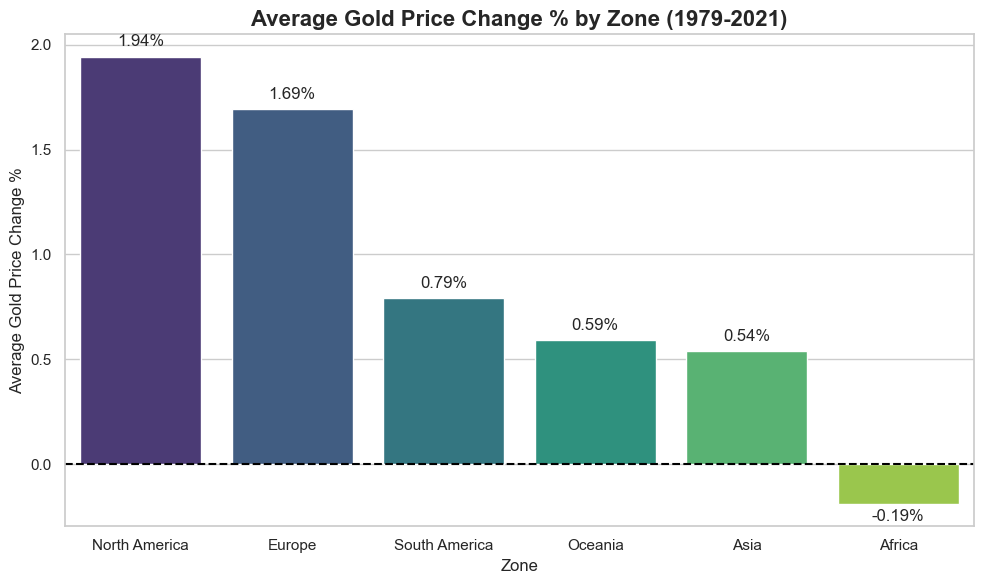

In [87]:
zone_impact = df.groupby("Zone")["Gold Change %"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=zone_impact.index,
    y=zone_impact.values,
    palette="viridis"
)

plt.title("Average Gold Price Change % by Zone (1979-2021)", fontsize=16, fontweight='bold')
plt.xlabel("Zone")
plt.ylabel("Average Gold Price Change %")

plt.axhline(0,color="black",linestyle="--")

# ใส่ตัวเลขบนกราฟ
for i, v in enumerate(zone_impact.values):
    ax.text(
        i,                      # ตำแหน่ง x (index ของ bar)
        v + 0.05 if v >= 0 else v - 0.08,  # ตำแหน่ง y
        f"{v:.2f}%",            # format ตัวเลข
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

100k USD When?

c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Gold may reach 100,000 THB around: 2064


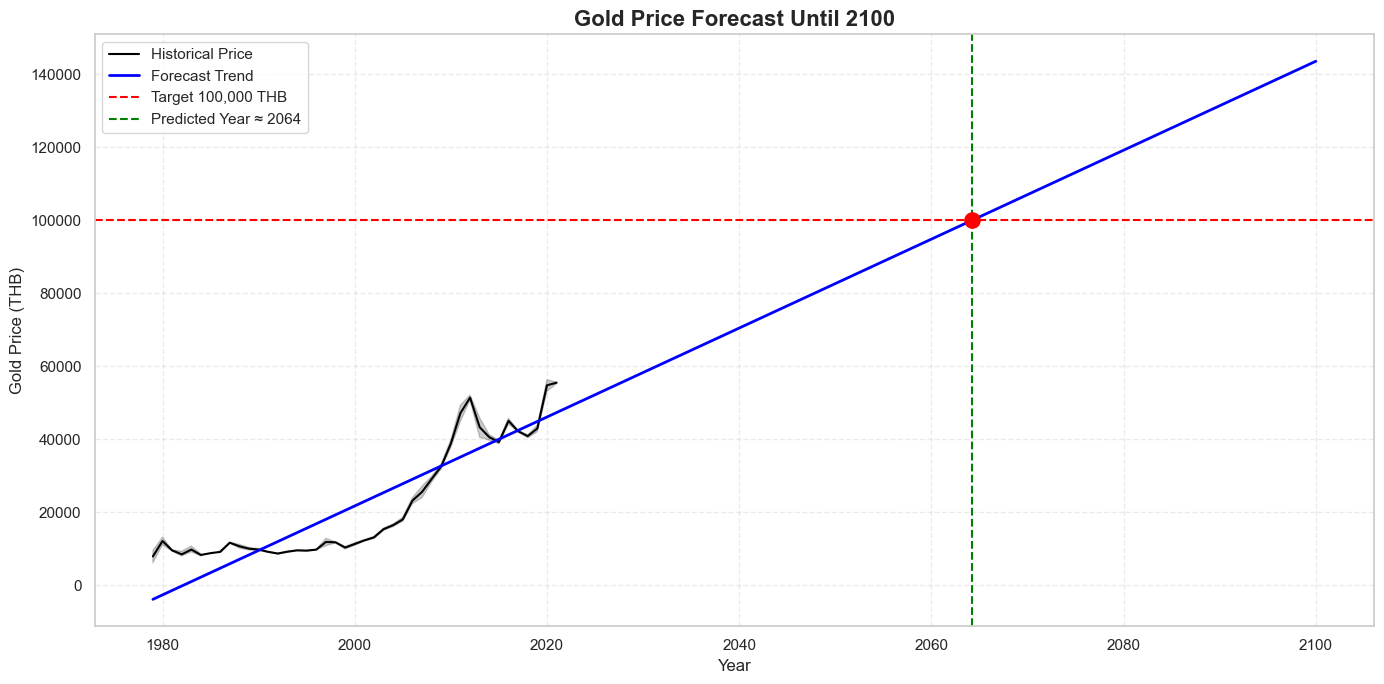

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# -----------------------------
# 1 Train Model
# -----------------------------
X = df[['Year']]
y = df['Price(THB)']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

# -----------------------------
# 2 หา year ที่ราคาจะถึง 100000
# -----------------------------
target_price = 100000
predicted_year = (target_price - intercept) / slope

print("Gold may reach 100,000 THB around:", int(predicted_year))

# -----------------------------
# 3 สร้างปี forecast ถึง 2050
# -----------------------------
future_years = np.arange(df['Year'].min(), 2101)

future_df = future_years.reshape(-1,1)

predicted_prices = model.predict(future_df)

# -----------------------------
# 4 Plot Graph
# -----------------------------
plt.figure(figsize=(14,7))

# ราคาจริง
sns.lineplot(
    x=df['Year'],
    y=df['Price(THB)'],
    color="black",
    label="Historical Price"
)

# เส้น trend
sns.lineplot(
    x=future_years,
    y=predicted_prices,
    color="blue",
    linewidth=2,
    label="Forecast Trend"
)

# เส้นราคา 100k
plt.axhline(
    target_price,
    color="red",
    linestyle="--",
    label="Target 100,000 THB"
)

# เส้นปีที่คาดการณ์
plt.axvline(
    predicted_year,
    color="green",
    linestyle="--",
    label=f"Predicted Year ≈ {int(predicted_year)}"
)

# จุดตัด
plt.scatter(
    predicted_year,
    target_price,
    color="red",
    s=120,
    zorder=5
)

plt.title(
    "Gold Price Forecast Until 2100",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Gold Price (THB)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()